We want to determine how detuning from the motion of the atom affects the central splitting when $g_{10} \gg g_{21}$.  Kevin's intuition is that the central peak should be unaffected by this detuning.  We can include the detuning from the doppler shift by adding it to the $\Delta_1$ and $\Delta_2$ terms, so the functions will be the same as we've used before.  The cavity laser is much smaller than the others (10 GHz vs 385 THz and 625 THz), so the doppler shift on the $|0,3\rangle$ state is negligible.

### Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg, optimize
import qutip as qu
import sympy as sym

In [2]:
# Set font size of plot elements\n",
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 18
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

### Functions

In [3]:
def gen_Hd(Δ1, Δ2, γ1, γ2, g10, g21):
    """
    function to generate the Hamiltonian corresponding to the |0,0>, |0,1>, and |0,2> states
    """
    return np.array([[0, g10, 0],
                     [g10, -Δ1 -1j*γ1, g21],
                     [0, g21, -Δ1 - Δ2 - 1j*γ2]])

In [4]:
def gen_H0(Δ1, Δ2, δc, κ, γ1, γ2, γ3, g10, g21, g32):
    """
    function to generate the Hamiltonian corresponding to the |1,0>, |1,1>, |1,2>, and |0,3> states
    """
    return np.array([[-1j*κ, g10, 0, 0],
                     [g10, -Δ1 -1j*κ - 1j*γ1, g21, 0],
                     [0, g21, -Δ1 -Δ2 -1j*κ -1j*γ2, g32],
                     [0, 0, g32, -Δ1 -Δ2 -δc -1j*γ3]])

### Main Results

In [5]:
# Define the coupling parameters - g10 >> g21, large g32
g10 = 50
g21 = 10
g32 = 50

In [6]:
# Define the lifetimes that we'll be using
κ = 1
γ1 = 1
γ2 = 0.05
γ3 = 0.05

# Define the rms velocity
vrms = 300 # m/s

# Define the frequencies
f01 = 385e6  # MHz
f02 = 625e6  # MHz

# Define the detunings - assuming that the doppler shift is the only source of the detunings
Δ1 = f01 / 3e8 * vrms # MHz
print(Δ1)
Δ2 = f02 / 3e8 * vrms # MHz
print(Δ2)

385.00000000000006
625.0


In [7]:
# Get the Hd both with and without detuning for comparison
Hd = gen_Hd(0, 0, γ1, γ2, g10, g21)
Hd_Doppler = gen_Hd(Δ1, Δ2, γ1, γ2, g10, g21)

In [8]:
# Get the eigenvalues and eigenvectors of each
Hd_eigs = linalg.eig(Hd)
print("Hd eigs: ", Hd_eigs)

Hd_Doppler_eigs = linalg.eig(Hd_Doppler)
print("Hd Doppler eigs: ", Hd_Doppler_eigs)

Hd eigs:  (array([ 5.09877521e+01-0.50096156j, -5.09877521e+01-0.50096156j,
       -1.32569496e-16-0.04807689j]), array([[ 6.93341537e-01+6.81217430e-03j, -6.93341537e-01+6.81217430e-03j,
        -1.96119584e-01+1.38777878e-17j],
       [ 7.07106781e-01+0.00000000e+00j,  7.07106781e-01+0.00000000e+00j,
         2.71050543e-18+1.88576390e-04j],
       [ 1.38670846e-01+1.22647533e-03j, -1.38670846e-01+1.22647533e-03j,
         9.80579968e-01+0.00000000e+00j]]))
Hd Doppler eigs:  (array([    6.38907159-0.01606592j,  -391.22847731-0.98368916j,
       -1010.16059428-0.05024492j]), array([[ 9.91933767e-01+0.00000000e+00j, -1.26754360e-01+3.18706069e-04j,
         7.94792114e-04+1.17257154e-06j],
       [ 1.26750717e-01-3.18726643e-04j,  9.91804575e-01+0.00000000e+00j,
        -1.60573523e-02-2.44883966e-05j],
       [ 1.24706876e-03-3.17750814e-06j,  1.60285708e-02+2.41861532e-05j,
         9.99870756e-01+0.00000000e+00j]]))


We can see that the eigenvalues and eigenvectors have changed quite a bit from adding in the detuning.  In particular, we see that we don't have an eigenvalue that is obviously close to 0 when we add in the detuning.  However, there is still one value that is much smaller than the other two.  We'll assume that this is the eigenvalue corresponding to the dark state when the atomic motion is considered.  Also note that the index of the eigenvector corresponding to the dark states is different between the results.  This is because scipy doesn't  sort the eigenvalues.

Actually, this choice doesn't seem to work very well because the corresponding eigenvector is essentially just the ground state and the transmission spectrum is basically just for the bare cavity.  In the case where we don't consider atomic motion, the dark state is essentially just the first Rydberg state.  In the case where we do consider atomic motion, we also have an eigenvector that is basically the Rydberg state.  If we pick that eigenvector, the transmission spectrum features the splitting that we expect from the dark state when there's no atomic motion.

In [9]:
# Now calculate H0 with and without the doppler shift
H0 = gen_H0(0, 0, 0, κ, γ1, γ2, γ3, g10, g21, g32)
H0_Doppler = gen_H0(Δ1, Δ2, 0, κ, γ1, γ2, γ3, g10, g21, g32)

In [10]:
# Create the cavity field vectors that we'll need for calculating the transmission spectra
eig_ind = 2
C = np.array([Hd_eigs[1].T[eig_ind][0], Hd_eigs[1].T[eig_ind][1], Hd_eigs[1].T[eig_ind][2], 0])
print("|C>: ", C)

eig_ind_Doppler = 2
C_Doppler = np.array([Hd_Doppler_eigs[1].T[eig_ind_Doppler][0], Hd_Doppler_eigs[1].T[eig_ind_Doppler][1],
                      Hd_Doppler_eigs[1].T[eig_ind_Doppler][2], 0])
print("|C_Doppler>: ", C_Doppler)

|C>:  [-1.96119584e-01+1.38777878e-17j  2.71050543e-18+1.88576390e-04j
  9.80579968e-01+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
|C_Doppler>:  [ 7.94792114e-04+1.17257154e-06j -1.60573523e-02-2.44883966e-05j
  9.99870756e-01+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]


In [11]:
# Now define the cavity laser detuning
δL = np.linspace(-100, 100, 1000)

In [12]:
# Create arrays for storing the transmission spectra
Ts = np.zeros(δL.shape[0])
Ts_Doppler = np.zeros(δL.shape[0])

# Now calculate the transmission spectra
for i in range(δL.shape[0]):
    temp = (δL[i] + Hd_eigs[0][eig_ind]) * np.eye(4) - H0
    temp_inv = np.linalg.inv(temp)
    Ts[i] = (κ / 2) ** 2 * np.abs(C.conj().T @ temp_inv @ C) ** 2

    temp_Doppler = (δL[i] + Hd_Doppler_eigs[0][eig_ind_Doppler]) * np.eye(4) - H0_Doppler
    temp_Doppler_inv = np.linalg.inv(temp_Doppler)
    Ts_Doppler[i] = (κ / 2 ) ** 2 * np.abs(C_Doppler.conj().T @ temp_Doppler_inv @ C_Doppler) ** 2

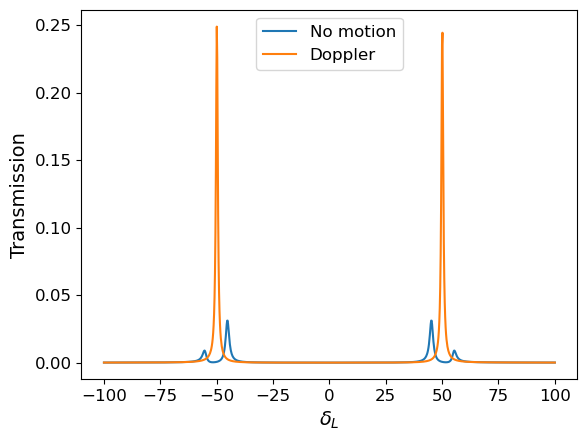

In [13]:
# Now plot
plt.plot(δL, Ts, label='No motion')
plt.plot(δL, Ts_Doppler, label='Doppler')
plt.xlabel("$\\delta_L$")
plt.ylabel("Transmission")
plt.legend()
plt.savefig("motion_comp_transmission_darkstate_g10=50_g21=10_g32=50.png", format='png', dpi=300)

So it seems that the location of the splitting is unchanged even if we consider atomic motion.  Let's try creating a waterfall plot to see how this changes as we vary $\delta_c$.

In [14]:
# Define δc - this can be kind of coarse for now
δc = np.linspace(-100, 100, 100)

In [15]:
# Define new arrays for storing transmission results
wf_Ts = np.zeros((δc.shape[0], δL.shape[0]), dtype=complex)
wf_Ts_D = np.zeros((δc.shape[0], δL.shape[0]), dtype=complex)

In [16]:
# Now calculate transmission values
for i in range(δc.shape[0]):
    # Create updated H0's
    temp_H0 = gen_H0(0, 0, δc[i], κ, γ1, γ2, γ3, g10, g21, g32)
    temp_H0_D = gen_H0(Δ1, Δ2, δc[i], κ, γ1, γ2, γ3, g10, g21, g32)

    for j in range(δL.shape[0]):
        temp = (δL[j] + Hd_eigs[0][eig_ind]) * np.eye(4) - temp_H0
        temp_inv = np.linalg.inv(temp)
        wf_Ts[i][j] = (κ / 2) ** 2 * np.abs(C.conj().T @ temp_inv @ C) ** 2

        temp_D = (δL[j] + Hd_Doppler_eigs[0][eig_ind_Doppler]) * np.eye(4) - temp_H0_D
        temp_D_inv = np.linalg.inv(temp_D)
        wf_Ts_D[i][j] = (κ / 2) ** 2 * np.abs(C_Doppler.conj().T @ temp_D_inv @ C_Doppler) ** 2

/home/jacob/anaconda3/envs/mode_cooling/lib/python3.11/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


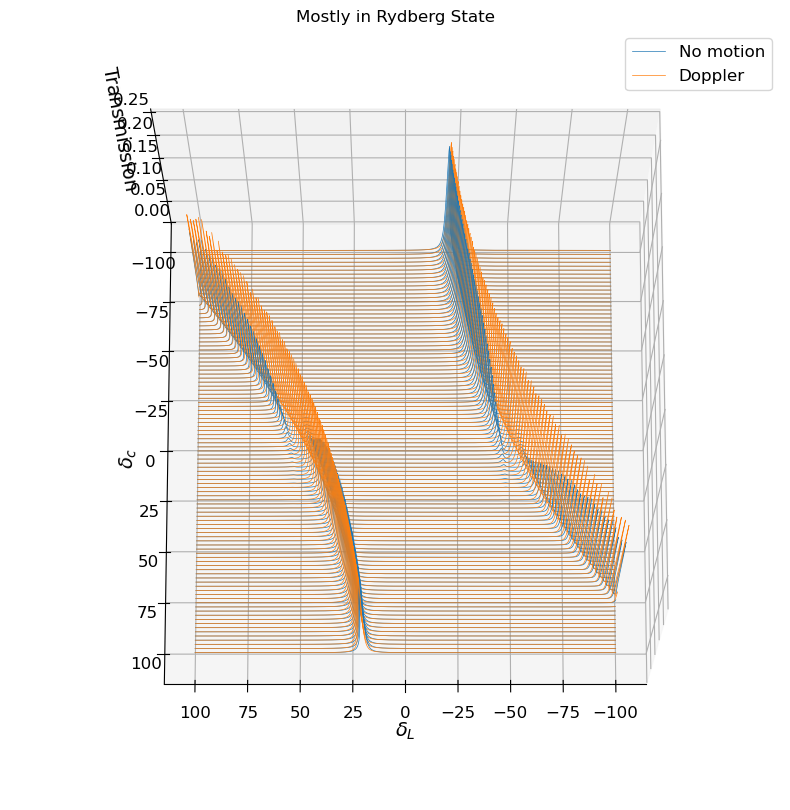

In [17]:
# Plot using 3d projection
fig = plt.figure(1, figsize=(10,10))
ax = fig.add_subplot(projection='3d')
ax.plot(δL, δc[0] * np.ones(δL.shape[0]), wf_Ts[0], linewidth=0.5, color='tab:blue', label='No motion')
ax.plot(δL, δc[0] * np.ones(δL.shape[0]), wf_Ts_D[0], linewidth=0.5, color='tab:orange', label='Doppler')
for i in range(1, δc.shape[0]):
    ax.plot(δL, δc[i] * np.ones(δL.shape[0]), wf_Ts[i], linewidth=0.5, color='tab:blue')
    ax.plot(δL, δc[i] * np.ones(δL.shape[0]), wf_Ts_D[i], linewidth=0.5, color='tab:orange')

ax.set_xlabel("$\\delta_L$")
ax.set_ylabel("$\\delta_c$")
ax.set_zlabel("Transmission")
ax.legend()
ax.view_init(elev=75, azim=90, roll=0)
ax.set_title("Mostly in Rydberg State")
fig.savefig("waterfall_plot_motion_comp_pertrubed_darkstate_g10=50_g21=10_g32=50.png", format='png', dpi=300)

It appears that the splitting of the transmission spectrum when we consider atomic motion follows the splitting of the transmission spectrum for the stationary atom as we shift $\delta_c$.

What do the eigenvalues of the 4 level system look like vs $\delta_c$ with and without Doppler broadening?

In [18]:
# Enlarge the range of δc
δc = np.linspace(-400, 400, 1000)

# Create arrays for storing eigenvalues
λs = np.zeros((δc.shape[0], 4), dtype=complex)
λs_D = np.zeros((δc.shape[0], 4), dtype=complex)

# Now loop over δc, generate H0 and H0_D, and get the eigenvalues
for i in range(δc.shape[0]):
    # Generate Hamiltonians
    temp_H0 = gen_H0(0, 0, δc[i], κ, γ1, γ2, γ3, g10, g21, g32)
    temp_H0_D = gen_H0(Δ1, Δ2, δc[i], κ, γ1, γ2, γ3, g10, g21, g32)

    # Get eigenvalues
    λs[i] = np.sort(linalg.eigvals(temp_H0))
    λs_D[i] = np.sort(linalg.eigvals(temp_H0_D))

In [40]:
print(λs_D.T[3][0], λs_D.T[2][0])

(6.389077920668713-1.016065945404359j) (-391.22548659146275-1.983652879279818j)


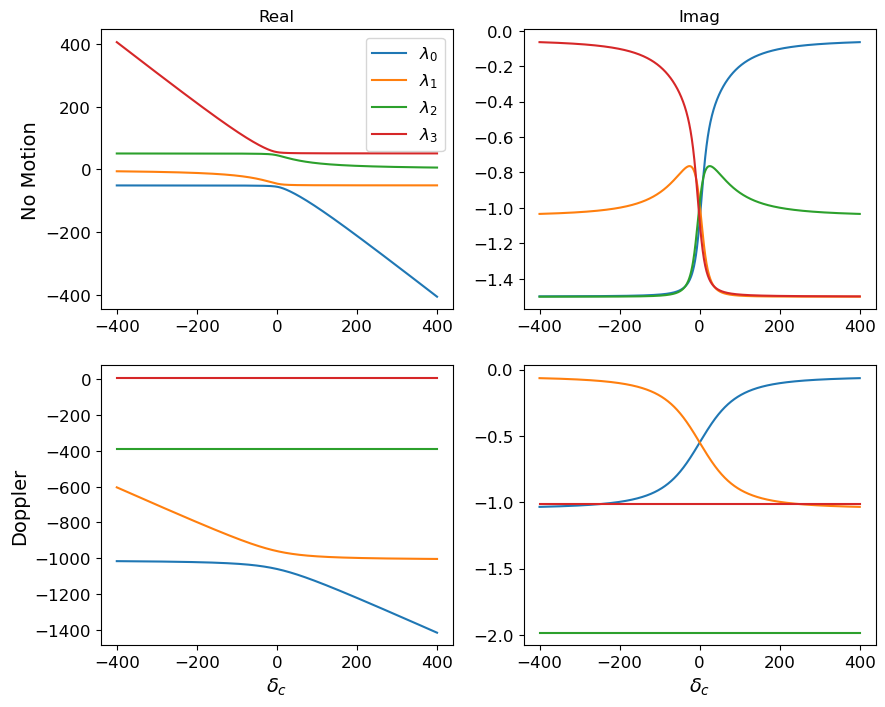

In [19]:
# Plot
fig = plt.figure(1, figsize=(10, 8))
ax = fig.subplots(2, 2)
for i in range(4):
    ax[0][0].plot(δc, λs.T[i].real, label='$\\lambda_'+str(i)+'$')
    ax[0][1].plot(δc, λs.T[i].imag)
    ax[1][0].plot(δc, λs_D.T[i].real)
    ax[1][1].plot(δc, λs_D.T[i].imag)
ax[1][0].set_xlabel("$\\delta_c$")
ax[1][1].set_xlabel("$\\delta_c$")
ax[0][0].set_ylabel("No Motion")
ax[1][0].set_ylabel("Doppler")
ax[0][0].set_title("Real")
ax[0][1].set_title("Imag")
ax[0][0].legend()
fig.savefig("motion_comp_eigvals_g10=50_g21=10_g32=50.png", dpi=300, format='png')

For completeness, it is probably a good idea to also create the waterfall plots for the other eigenstates.  We would expect the transmission spectra from those states to be the bare cavity.

In [20]:
# Now define the cavity laser detuning
δL = np.linspace(-100, 100, 1000)

In [21]:
# Need to redefine the cavity vectors
eig_ind = 1
bsp = np.array([Hd_eigs[1].T[eig_ind][0], Hd_eigs[1].T[eig_ind][1], Hd_eigs[1].T[eig_ind][2], 0])
print("|B+>: ", bsp)

eig_ind_Doppler = 1
bsp_D = np.array([Hd_Doppler_eigs[1].T[eig_ind_Doppler][0], Hd_Doppler_eigs[1].T[eig_ind_Doppler][1],
                      Hd_Doppler_eigs[1].T[eig_ind_Doppler][2], 0])
print("|B+_Doppler>: ", bsp_D)

|B+>:  [-0.69334154+0.00681217j  0.70710678+0.j         -0.13867085+0.00122648j
  0.        +0.j        ]
|B+_Doppler>:  [-0.12675436+3.18706069e-04j  0.99180457+0.00000000e+00j
  0.01602857+2.41861532e-05j  0.        +0.00000000e+00j]


In [22]:
# Create arrays for storing the transmission spectra
Ts_1 = np.zeros(δL.shape[0])
Ts_D_1 = np.zeros(δL.shape[0])

# Now calculate the transmission spectra
for i in range(δL.shape[0]):
    temp = (δL[i] + Hd_eigs[0][eig_ind]) * np.eye(4) - H0
    temp_inv = np.linalg.inv(temp)
    Ts_1[i] = (κ / 2) ** 2 * np.abs(bsp.conj().T @ temp_inv @ bsp) ** 2

    temp_Doppler = (δL[i] + Hd_Doppler_eigs[0][eig_ind_Doppler]) * np.eye(4) - H0_Doppler
    temp_Doppler_inv = np.linalg.inv(temp_Doppler)
    Ts_D_1[i] = (κ / 2 ) ** 2 * np.abs(bsp_D.conj().T @ temp_Doppler_inv @ bsp_D) ** 2

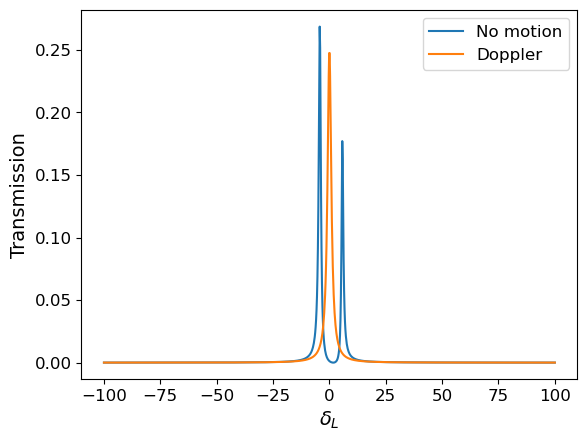

In [23]:
# Now plot
plt.plot(δL, Ts_1, label='No motion')
plt.plot(δL, Ts_D_1, label='Doppler')
plt.xlabel("$\\delta_L$")
plt.ylabel("Transmission")
plt.legend()
plt.savefig("motion_comp_transmission_brightstate_g10=50_g21=10_g32=50.png", format='png', dpi=300)

In [24]:
# Define δc - this can be kind of coarse for now
δc = np.linspace(-100, 100, 100)

In [25]:
# Define new arrays for storing transmission results
wf_Ts_1 = np.zeros((δc.shape[0], δL.shape[0]), dtype=complex)
wf_Ts_D_1 = np.zeros((δc.shape[0], δL.shape[0]), dtype=complex)

In [26]:
# Now calculate transmission values
for i in range(δc.shape[0]):
    # Create updated H0's
    temp_H0 = gen_H0(0, 0, δc[i], κ, γ1, γ2, γ3, g10, g21, g32)
    temp_H0_D = gen_H0(Δ1, Δ2, δc[i], κ, γ1, γ2, γ3, g10, g21, g32)

    for j in range(δL.shape[0]):
        temp = (δL[j] + Hd_eigs[0][eig_ind]) * np.eye(4) - temp_H0
        temp_inv = np.linalg.inv(temp)
        wf_Ts_1[i][j] = (κ / 2) ** 2 * np.abs(bsp.conj().T @ temp_inv @ bsp) ** 2

        temp_D = (δL[j] + Hd_Doppler_eigs[0][eig_ind_Doppler]) * np.eye(4) - temp_H0_D
        temp_D_inv = np.linalg.inv(temp_D)
        wf_Ts_D_1[i][j] = (κ / 2) ** 2 * np.abs(bsp_D.conj().T @ temp_D_inv @ bsp_D) ** 2

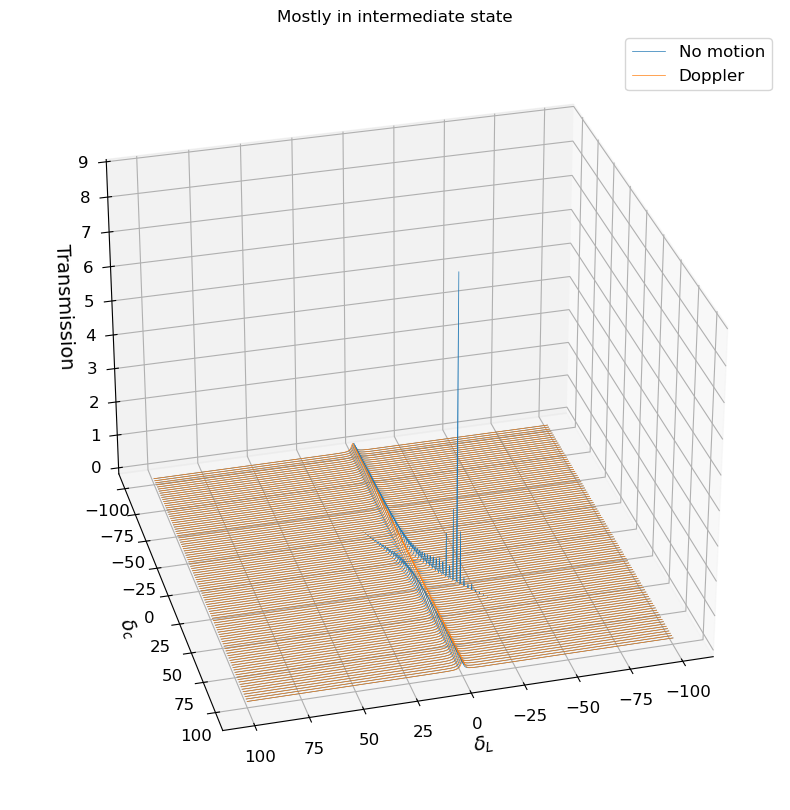

In [27]:
# Plot using 3d projection
fig = plt.figure(1, figsize=(10,10))
ax = fig.add_subplot(projection='3d')
ax.plot(δL, δc[0] * np.ones(δL.shape[0]), wf_Ts_1[0], linewidth=0.5, color='tab:blue', label='No motion')
ax.plot(δL, δc[0] * np.ones(δL.shape[0]), wf_Ts_D_1[0], linewidth=0.5, color='tab:orange', label='Doppler')
for i in range(1, δc.shape[0]):
    ax.plot(δL, δc[i] * np.ones(δL.shape[0]), wf_Ts_1[i], linewidth=0.5, color='tab:blue')
    ax.plot(δL, δc[i] * np.ones(δL.shape[0]), wf_Ts_D_1[i], linewidth=0.5, color='tab:orange')

ax.set_xlabel("$\\delta_L$")
ax.set_ylabel("$\\delta_c$")
ax.set_zlabel("Transmission")
ax.legend()
ax.view_init(elev=30, azim=75, roll=0)
ax.set_title("Mostly in intermediate state")
fig.savefig("waterfall_plot_motion_comp_pertrubed_brightstate_g10=50_g21=10_g32=50.png", format='png', dpi=300)

Let's try and zoom in on the peak and look at the imaginary part of the eigenvalue to see if we should be seeing gain there.  After zooming in, it looks like the peak occurs around $\delta_L = -16$ and $\delta_c = 28$.

In [28]:
δL = -16
δc = 28
test = gen_H0(0, 0, δc, κ, γ1, γ2, γ3, g10, g21, g32)
linalg.eig(H0)

(array([ 55.2245079 -1.07497807j,  45.26927736-0.97502193j,
        -55.2245079 -1.07497807j, -45.26927736-0.97502193j]),
 array([[ 0.4747921 +0.00064462j, -0.52203338-0.0442888j ,
         -0.4747921 +0.00064462j,  0.52203338-0.0442888j ],
        [ 0.52440416+0.j        , -0.47261935-0.04035923j,
          0.52440416+0.j        , -0.47261935+0.04035923j],
        [ 0.52203571+0.04528542j,  0.47478998-0.00970175j,
         -0.52203571+0.04528542j, -0.47478998-0.00970175j],
        [ 0.47172509+0.04975651j,  0.52440641+0.j        ,
          0.47172509-0.04975651j,  0.52440641+0.j        ]]))

In [29]:
# Now define the cavity laser detuning
δL = np.linspace(-100, 100, 1000)

In [30]:
# Need to redefine the cavity vectors
eig_ind = 0
bsm = np.array([Hd_eigs[1].T[eig_ind][0], Hd_eigs[1].T[eig_ind][1], Hd_eigs[1].T[eig_ind][2], 0])
print("|B->: ", bsm)

eig_ind_Doppler = 0
bsm_D = np.array([Hd_Doppler_eigs[1].T[eig_ind_Doppler][0], Hd_Doppler_eigs[1].T[eig_ind_Doppler][1],
                      Hd_Doppler_eigs[1].T[eig_ind_Doppler][2], 0])
print("|B-_Doppler>: ", bsm_D)

|B->:  [0.69334154+0.00681217j 0.70710678+0.j         0.13867085+0.00122648j
 0.        +0.j        ]
|B-_Doppler>:  [0.99193377+0.00000000e+00j 0.12675072-3.18726643e-04j
 0.00124707-3.17750814e-06j 0.        +0.00000000e+00j]


In [31]:
# Define δc - this can be kind of coarse for now
δc = np.linspace(-100, 100, 100)

In [32]:
# Create arrays for storing the transmission spectra
Ts_2 = np.zeros(δL.shape[0])
Ts_D_2 = np.zeros(δL.shape[0])

# Now calculate the transmission spectra
for i in range(δL.shape[0]):
    temp = (δL[i] + Hd_eigs[0][eig_ind]) * np.eye(4) - H0
    temp_inv = np.linalg.inv(temp)
    Ts_2[i] = (κ / 2) ** 2 * np.abs(bsm.conj().T @ temp_inv @ bsm) ** 2

    temp_Doppler = (δL[i] + Hd_Doppler_eigs[0][eig_ind_Doppler]) * np.eye(4) - H0_Doppler
    temp_Doppler_inv = np.linalg.inv(temp_Doppler)
    Ts_D_2[i] = (κ / 2 ) ** 2 * np.abs(bsm_D.conj().T @ temp_Doppler_inv @ bsm_D) ** 2

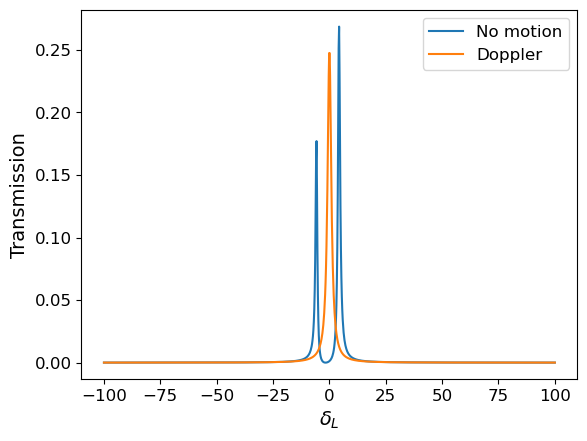

In [33]:
# Now plot
plt.plot(δL, Ts_2, label='No motion')
plt.plot(δL, Ts_D_2, label='Doppler')
plt.xlabel("$\\delta_L$")
plt.ylabel("Transmission")
plt.legend()

In [34]:
# Define δc - this can be kind of coarse for now
δc = np.linspace(-100, 100, 100)

In [35]:
# Define new arrays for storing transmission results
wf_Ts_2 = np.zeros((δc.shape[0], δL.shape[0]), dtype=complex)
wf_Ts_D_2 = np.zeros((δc.shape[0], δL.shape[0]), dtype=complex)

In [36]:
# Now calculate transmission values
for i in range(δc.shape[0]):
    # Create updated H0's
    temp_H0 = gen_H0(0, 0, δc[i], κ, γ1, γ2, γ3, g10, g21, g32)
    temp_H0_D = gen_H0(Δ1, Δ2, δc[i], κ, γ1, γ2, γ3, g10, g21, g32)

    for j in range(δL.shape[0]):
        temp = (δL[j] + Hd_eigs[0][eig_ind]) * np.eye(4) - temp_H0
        temp_inv = np.linalg.inv(temp)
        wf_Ts_2[i][j] = (κ / 2) ** 2 * np.abs(bsm.conj().T @ temp_inv @ bsm) ** 2

        temp_D = (δL[j] + Hd_Doppler_eigs[0][eig_ind_Doppler]) * np.eye(4) - temp_H0_D
        temp_D_inv = np.linalg.inv(temp_D)
        wf_Ts_D_2[i][j] = (κ / 2) ** 2 * np.abs(bsm_D.conj().T @ temp_D_inv @ bsm_D) ** 2

Text(0.5, 0.92, 'Mostly in ground state')

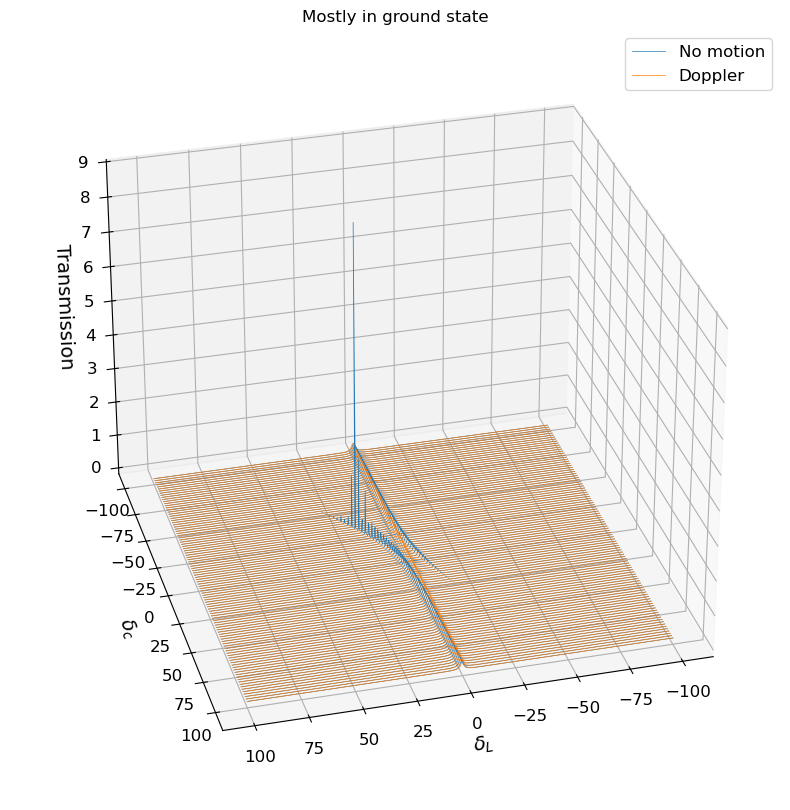

In [37]:
# Plot using 3d projection
fig = plt.figure(1, figsize=(10,10))
ax = fig.add_subplot(projection='3d')
ax.plot(δL, δc[0] * np.ones(δL.shape[0]), wf_Ts_2[0], linewidth=0.5, color='tab:blue', label='No motion')
ax.plot(δL, δc[0] * np.ones(δL.shape[0]), wf_Ts_D_2[0], linewidth=0.5, color='tab:orange', label='Doppler')
for i in range(1, δc.shape[0]):
    ax.plot(δL, δc[i] * np.ones(δL.shape[0]), wf_Ts_2[i], linewidth=0.5, color='tab:blue')
    ax.plot(δL, δc[i] * np.ones(δL.shape[0]), wf_Ts_D_2[i], linewidth=0.5, color='tab:orange')

ax.set_xlabel("$\\delta_L$")
ax.set_ylabel("$\\delta_c$")
ax.set_zlabel("Transmission")
ax.legend()
ax.view_init(elev=30, azim=75, roll=0)
ax.set_title("Mostly in ground state")

So it seems like there's a singularity or something in the zero atomic motion case using these coupling parameters.  Increasing the resolution of $\delta_c$ increases the transmission by about a factor of 10.  As expected, the transmission spectra of these is essentially just the bare cavity when we consider the atomic motion.  It also appears that as $\delta_c$ increases, the transmission spectra of the case with no atomic motion also shifts towards the bare cavity case.